# Module 4: Push Notifications - Model POC
First we import the libraries and the data path of the dataset.

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

# Standard library
from pathlib import Path
from typing import Tuple, Optional

# Sklearn: models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

# Sklearn: model selection
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

# Sklearn: preprocessing & pipelines
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline, make_pipeline

# Sklearn: calibration
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

# Sklearn: metrics
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    precision_recall_fscore_support,
    average_precision_score,
    log_loss,
    auc,
)

In [2]:
def find_project_root() -> Path:
    for parent in [Path.cwd(), *Path.cwd().parents]:
        if (parent / 'pyproject.toml').exists():
            return parent
    raise FileNotFoundError('pyproject.toml is not in project root')

PROJECT_ROOT = find_project_root()
data_path = PROJECT_ROOT / 'data/raw' # data is loaded in this folder

In [3]:
feature_frame = pd.read_csv(f"{data_path}/feature_frame.csv")
df = feature_frame

We change to datetime "order_date" and "created_at". So it's easier to work with them with pandas.

In [4]:
df["order_date"] = pd.to_datetime(df["order_date"]).apply(lambda x: x.date())
df["created_at"] = pd.to_datetime(df["created_at"])

In [5]:
df.head()

,variant_id,product_type,order_id,user_id,created_at,order_date,user_order_seq,outcome,ordered_before,abandoned_before,...,count_children,count_babies,count_pets,people_ex_baby,days_since_purchase_variant_id,avg_days_to_buy_variant_id,std_days_to_buy_variant_id,days_since_purchase_product_type,avg_days_to_buy_product_type,std_days_to_buy_product_type
0,33826472919172,ricepastapulses,2807985930372,3482464092292,2020-10-05 16:46:19,2020-10-05,3,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
1,33826472919172,ricepastapulses,2808027644036,3466586718340,2020-10-05 17:59:51,2020-10-05,2,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
2,33826472919172,ricepastapulses,2808099078276,3481384026244,2020-10-05 20:08:53,2020-10-05,4,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
3,33826472919172,ricepastapulses,2808393957508,3291363377284,2020-10-06 08:57:59,2020-10-06,2,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
4,33826472919172,ricepastapulses,2808429314180,3537167515780,2020-10-06 10:37:05,2020-10-06,3,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2880549 entries, 0 to 2880548
Data columns (total 27 columns):
 #   Column                            Dtype         
---  ------                            -----         
 0   variant_id                        int64         
 1   product_type                      object        
 2   order_id                          int64         
 3   user_id                           int64         
 4   created_at                        datetime64[ns]
 5   order_date                        object        
 6   user_order_seq                    int64         
 7   outcome                           float64       
 8   ordered_before                    float64       
 9   abandoned_before                  float64       
 10  active_snoozed                    float64       
 11  set_as_regular                    float64       
 12  normalised_price                  float64       
 13  discount_pct                      float64       
 14  vendor            

In [7]:
# here we are filtering by users that purchase the promoted item as part of a basket of at least 5 items.
min_products = 5 # We can change this value if we needed
order_size = df.groupby("order_id").outcome.sum()
orders_of_min_size = order_size[order_size >= min_products].index

# Apply the filter to the dataframe
df_filtered = df[df["order_id"].isin(orders_of_min_size)]

print(f"Orders before: {df['order_id'].nunique()}, after: {df_filtered['order_id'].nunique()}")
print(f"Rows before: {len(df)}, after: {len(df_filtered)}")
df.order_id.nunique() > df_filtered.order_id.nunique()

Orders before: 3446, after: 2603
Rows before: 2880549, after: 2163953


True

`reduced_cols = ["ordered_before", "global_popularity", "abandoned_before"]` was established in the prior linear model analysis as achieving comparable validation AP to the full feature set at significantly lower complexity. We carry this forward here as the fixed feature set for all models.

In [8]:
feature_columns = [
    "product_type", "user_order_seq",  "ordered_before", "abandoned_before", "active_snoozed", "set_as_regular", "normalised_price",
     "discount_pct", "vendor", "global_popularity", "count_adults", "count_children", "count_babies", "count_pets", "people_ex_baby", 
      "days_since_purchase_variant_id", "avg_days_to_buy_variant_id", "std_days_to_buy_variant_id", "days_since_purchase_product_type",
        "avg_days_to_buy_product_type", "std_days_to_buy_product_type"]

reduced_cols = ["ordered_before", "global_popularity", "abandoned_before"]
label_column = ["outcome"]
categoric_columns = ["product_type", "vendor"]
binary_columns = ["ordered_before", "abandoned_before", "active_snoozed", "set_as_regular"]
numerical_cols = [col for col in feature_columns if col not in (categoric_columns + binary_columns)]

columns = numerical_cols + binary_columns

We use the same train/validation/test split as in the previous analysis to ensure consistency and comparability of results. This allows us to fairly evaluate improvements over prior models without introducing variability from different data partitions, while maintaining a leakage-free setup.

In [9]:
daily_orders = df_filtered.groupby("order_date").order_id.nunique()
cum_sum_daily_orders = daily_orders.cumsum() / daily_orders.sum()
# Split at ~70% to keep the entire Valentine's Day period in the validation set
cutoff_train = cum_sum_daily_orders[cum_sum_daily_orders <= 0.70].index[-1]
cutoff_val   = cum_sum_daily_orders[cum_sum_daily_orders <= 0.90].index[-1]

# Temporal split based on cutoff dates
df_train = df_filtered[df_filtered["order_date"] <= cutoff_train]
df_val = df_filtered[(df_filtered["order_date"] > cutoff_train) & (df_filtered["order_date"] <= cutoff_val)]
df_test = df_filtered[df_filtered["order_date"] > cutoff_val]

# Print date ranges for each split
# .min() and .max() already return date objects, so no need for .date()
print(f"Train: {df_train['order_date'].min()} → {df_train['order_date'].max()}")
print(f"Val:   {df_val['order_date'].min()} → {df_val['order_date'].max()}")
print(f"Test:  {df_test['order_date'].min()} → {df_test['order_date'].max()}")

Train: 2020-10-05 → 2021-02-04
Val:   2021-02-05 → 2021-02-22
Test:  2021-02-23 → 2021-03-03


In [10]:
X_train, y_train = df_train[reduced_cols], df_train[label_column].values.ravel()
X_val, y_val = df_val[reduced_cols], df_val[label_column].values.ravel()
X_test, y_test = df_test[reduced_cols], df_test[label_column].values.ravel()

We use the same evaluation function (ROC and Precision-Recall curves) when assessing non-linear models to ensure consistency and comparability with previous results.

In [11]:
def plot_metrics(
    model_name: str,
    y_pred: np.ndarray,
    y: np.ndarray,
    target_precision: float = 0.05,
    figure: Optional[Tuple[matplotlib.figure.Figure, np.ndarray]] = None,
    add_baselines: bool = True,
    log_loss_train: Optional[float] = None,
    log_loss_val: Optional[float] = None,
) -> None:
    y_pred = np.asarray(y_pred)
    y = np.asarray(y)

    if figure is None:
        fig, axes = plt.subplots(1, 2, figsize=(18, 5))
        show = True
        add_baselines = True
    else:
        fig, axes = figure
        show = False

    # ── Panel 1: ROC Curve ───────────────────────────────────────────
    if add_baselines:
        axes[0].plot([0, 1], [0, 1], "k--", label="Random")

    fpr, tpr, _ = roc_curve(y, y_pred)
    roc_auc = roc_auc_score(y, y_pred) # ROC Metric
    axes[0].plot(fpr, tpr, label=f"{model_name} (AUC={roc_auc:.3f})")
    axes[0].set(xlabel="False Positive Rate", ylabel="True Positive Rate", title="ROC Curve")
    axes[0].legend()

    # ── Panel 2: Precision-Recall Curve ─────────────────────────────
    if add_baselines:
        axes[1].axhline(
            y=target_precision, color="r", linestyle="--",
            label=f"Target precision ({target_precision:.2f})"
        )

    precision, recall, _ = precision_recall_curve(y, y_pred)
    ap = average_precision_score(y, y_pred) # APS Metric (Average Precision Score)
    axes[1].plot(recall, precision, label=f"{model_name} (AP={ap:.3f})")
    axes[1].set(xlabel="Recall", ylabel="Precision", title="Precision-Recall Curve")
    axes[1].legend()


    plt.tight_layout()
    if show:
        plt.show()

# Baseline 
### Ridge
We use the Logistic Regression (L2 regularization) model from the previous analysis as our baseline, as it provided the best trade-off between performance and stability, consistently outperforming other linear models.

Best Ridge     : C = 2.15e+01
CV log loss    : 0.0586 ± 0.0238
Train log loss : 0.0671
Val   log loss : 0.0619


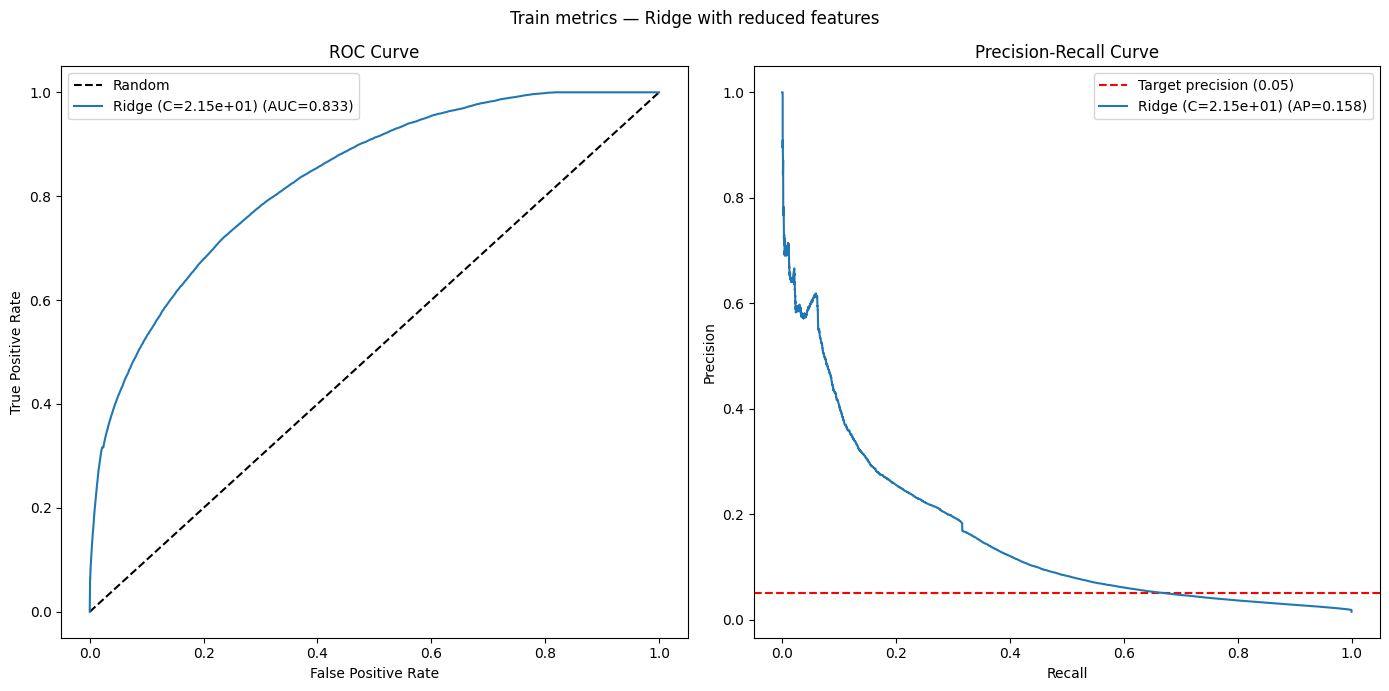

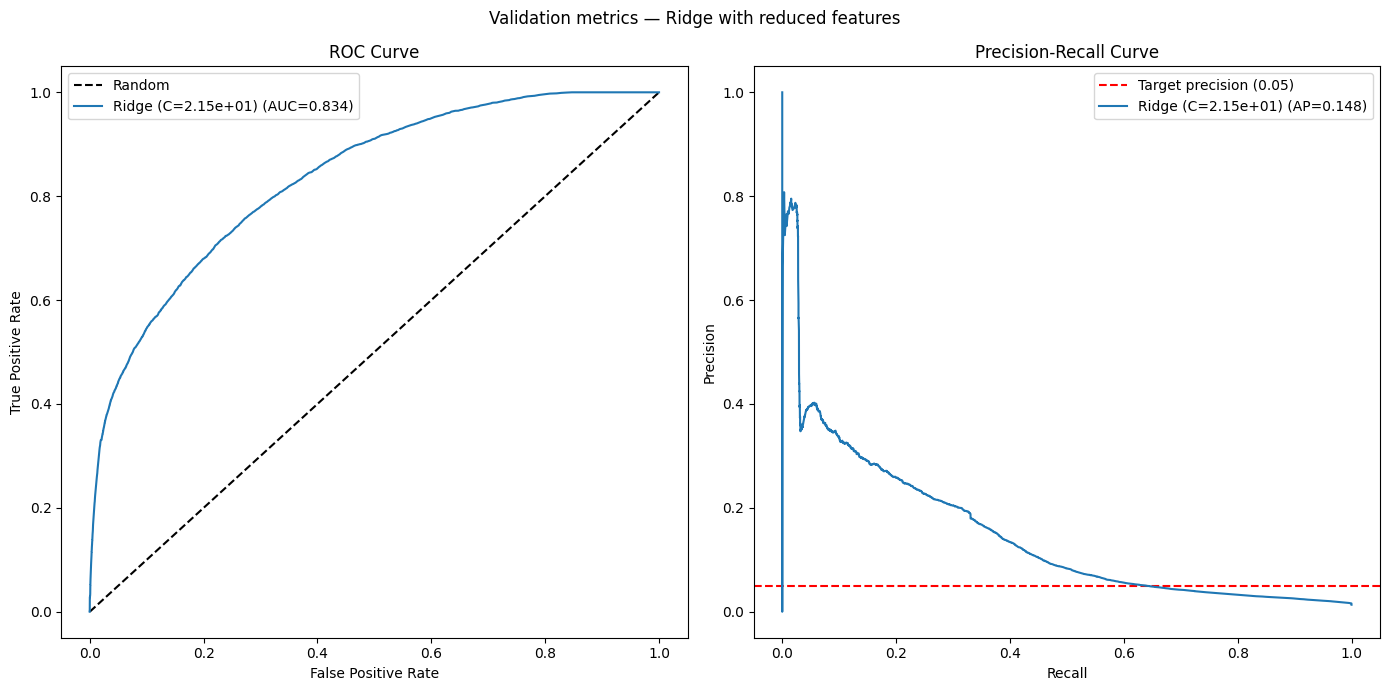

In [12]:
C_values_ridge = np.logspace(-8, 4, 10)

# TimeSeriesSplit respects temporal order: each fold's train always
# precedes its validation in time.
tscv = TimeSeriesSplit(n_splits=5)

best_ridge = {
    "C": None,
    "cv_logloss": np.inf,
    "cv_logloss_std": None,
    "model": None,
}

for C in C_values_ridge:
    ridge = make_pipeline(
        StandardScaler(),
        LogisticRegression(penalty="l2", C=C, max_iter=1000, solver="saga")
    )

    cv_scores = cross_val_score(
    ridge, X_train, y_train,
    cv=tscv, scoring="neg_log_loss", n_jobs=-1
    )

    cv_logloss = -cv_scores.mean()
    cv_logloss_std = cv_scores.std()

    if cv_logloss < best_ridge["cv_logloss"]:
        best_ridge = {
            "C": C,
            "cv_logloss": cv_logloss,
            "cv_logloss_std": cv_logloss_std,
            "model": ridge,
        }

# Fit best model on full training set
best_ridge["model"].fit(X_train, y_train)

train_proba = best_ridge["model"].predict_proba(X_train)[:, 1]
val_proba   = best_ridge["model"].predict_proba(X_val)[:, 1]

train_logloss = log_loss(y_train, train_proba)
val_logloss   = log_loss(y_val, val_proba)

print(f"Best Ridge     : C = {best_ridge['C']:.2e}")
print(f"CV log loss    : {best_ridge['cv_logloss']:.4f} ± {best_ridge['cv_logloss_std']:.4f}")
print(f"Train log loss : {train_logloss:.4f}")
print(f"Val   log loss : {val_logloss:.4f}")

model_name = f"Ridge (C={best_ridge['C']:.2e})"

fig_train, ax_train = plt.subplots(1, 2, figsize=(14, 7))
fig_train.suptitle("Train metrics — Ridge with reduced features")
plot_metrics(model_name, y_pred=train_proba, y=y_train, figure=(fig_train, ax_train))

fig_val, ax_val = plt.subplots(1, 2, figsize=(14, 7))
fig_val.suptitle("Validation metrics — Ridge with reduced features")
plot_metrics(model_name, y_pred=val_proba, y=y_val, figure=(fig_val, ax_val))

plt.show()

# Non Linear Models

- Linear models set the baseline — now let's see how far non-linear models can take us.
- We will explore Random Forest first. 

### Random Forest

Random Forest reduces bias by averaging multiple decision trees, making it robust against overfitting.

RF n_trees=  5 | Train Cross Entropy loss: 0.0597 | Val Cross Entropy: 0.1368
RF n_trees= 25 | Train Cross Entropy loss: 0.0588 | Val Cross Entropy: 0.1270
RF n_trees= 50 | Train Cross Entropy loss: 0.0588 | Val Cross Entropy: 0.1235
RF n_trees=100 | Train Cross Entropy loss: 0.0587 | Val Cross Entropy: 0.1210


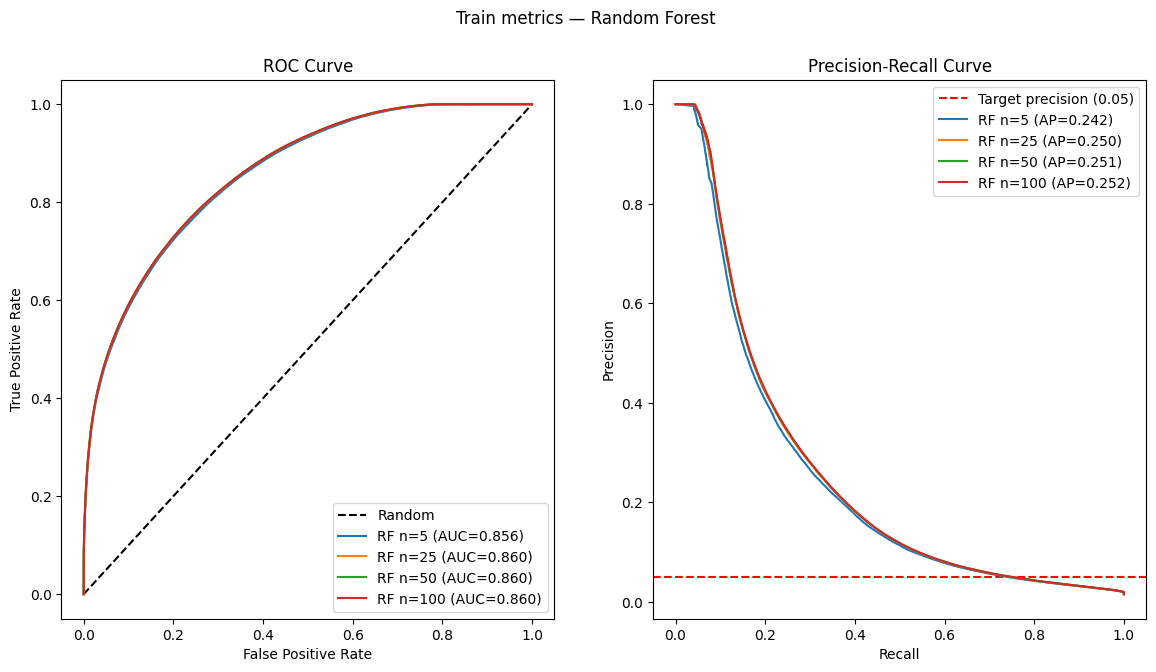

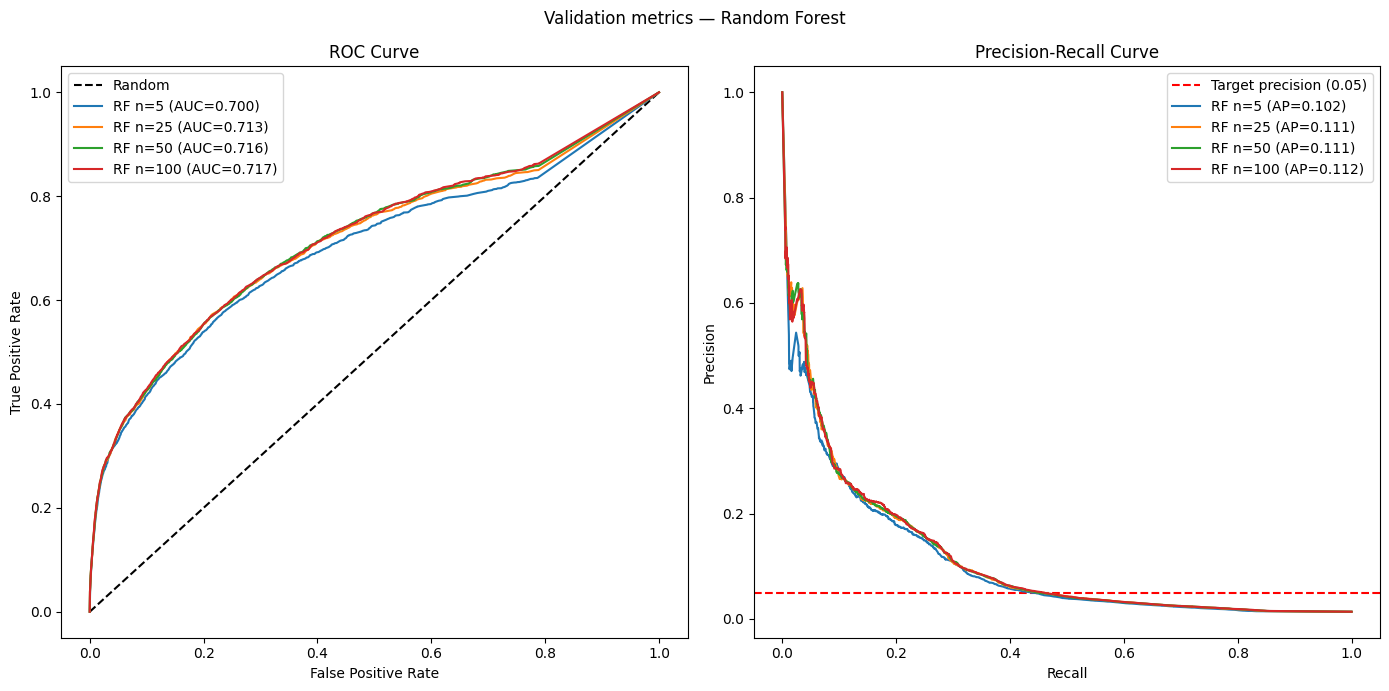

In [13]:
n_trees_grid = [5, 25, 50, 100]

fig_train, ax_train = plt.subplots(1, 2, figsize=(14, 7))
fig_train.suptitle("Train metrics — Random Forest")
fig_val, ax_val = plt.subplots(1, 2, figsize=(14, 7))
fig_val.suptitle("Validation metrics — Random Forest")

for i, n_trees in enumerate(n_trees_grid):
    rf = RandomForestClassifier(
        n_estimators=n_trees,
    )

    rf.fit(X_train, y_train)

    train_proba = rf.predict_proba(X_train)[:, 1]
    val_proba   = rf.predict_proba(X_val)[:, 1]

    train_logloss = log_loss(y_train, train_proba)
    val_logloss   = log_loss(y_val,   val_proba)

    print(f"RF n_trees={n_trees:>3} | Train Cross Entropy loss: {train_logloss:.4f} | Val Cross Entropy: {val_logloss:.4f}")

    plot_metrics(f"RF n={n_trees}", y_pred=train_proba, y=y_train,
                 figure=(fig_train, ax_train), add_baselines= (i==0))
    plot_metrics(f"RF n={n_trees}", y_pred=val_proba,   y=y_val,
                 figure=(fig_val, ax_val),     add_baselines= (i==0))

plt.tight_layout()
plt.show()

Random Forest with few trees is performing poorly, probably is suffering from variance

### Gradient Boosting Trees

 n_trees  depth   lr  train_ap   val_ap
     100      5 0.10  0.189652 0.163101
     100      5 0.05  0.186052 0.162770
     100      3 0.05  0.179130 0.162756
      50      5 0.10  0.185263 0.162440
     100      3 0.10  0.180417 0.162056
      50      5 0.05  0.180950 0.161657
      50      3 0.10  0.177969 0.160839
      50      3 0.05  0.176669 0.160686
      25      5 0.10  0.180160 0.160593
      25      5 0.05  0.176246 0.159025
       5      5 0.10  0.174747 0.157474
      25      3 0.10  0.172512 0.156875
     100      1 0.10  0.168101 0.156194
      25      3 0.05  0.170053 0.155731
     100      1 0.05  0.167848 0.155652
      50      1 0.10  0.166482 0.155033
       5      5 0.05  0.171033 0.154549
       5      3 0.10  0.159257 0.147989
      25      1 0.10  0.157241 0.143678
      50      1 0.05  0.155376 0.141767
       5      3 0.05  0.152235 0.138738
      25      1 0.05  0.133181 0.121442
       5      1 0.05  0.090888 0.076272
       5      1 0.10  0.090888 0.076272


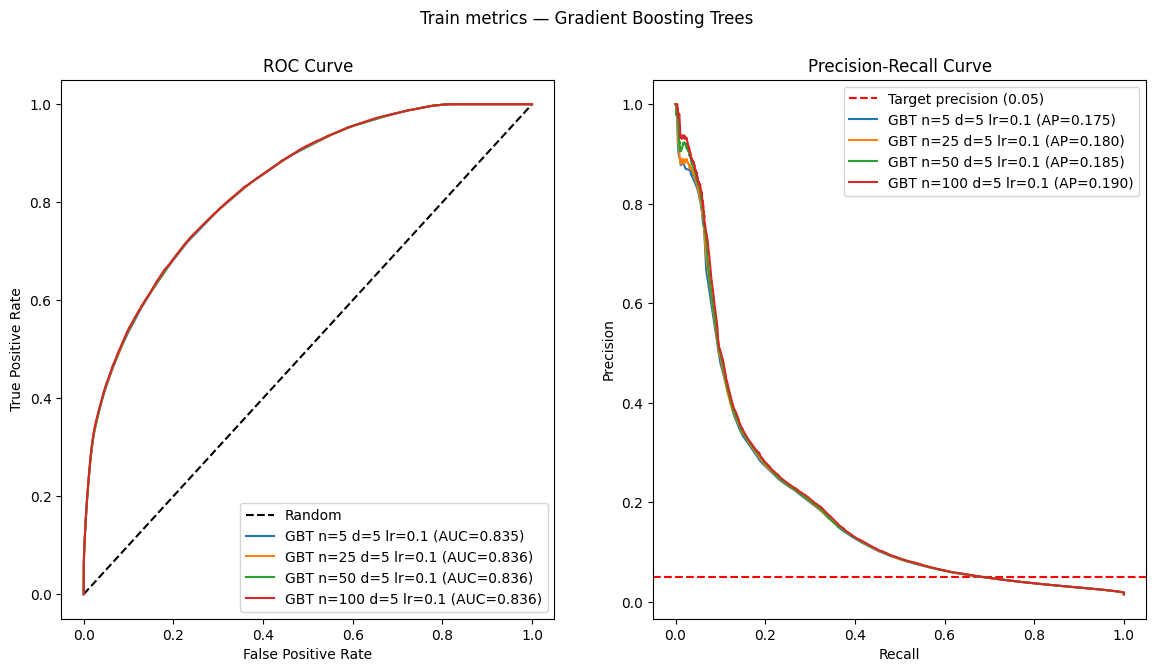

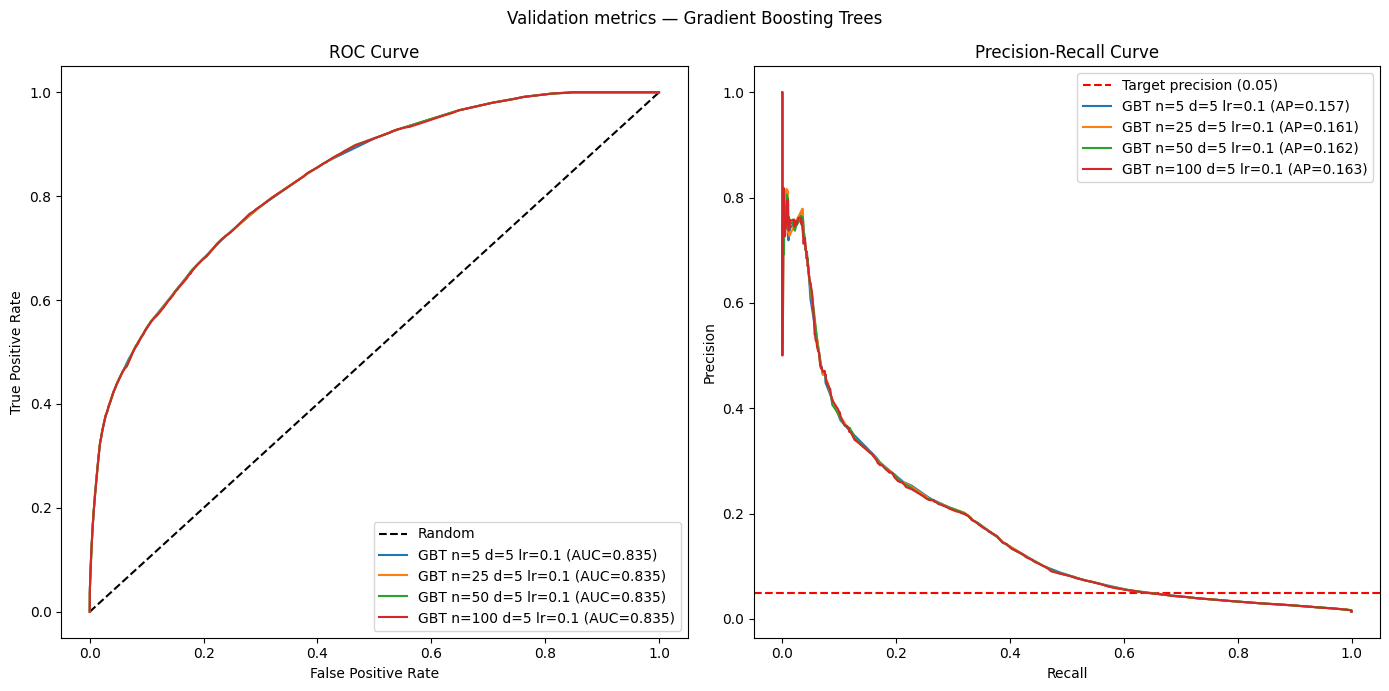

In [14]:
n_trees_grid = [5, 25, 50, 100]
results = []

# ── 1. Full grid search — no plotting yet ────────────────────────────────
for lr in [0.05, 0.1]:
    for depth in [1, 3, 5]:
        for n_trees in n_trees_grid:
            gbt = GradientBoostingClassifier(
                n_estimators=n_trees,
                max_depth=depth,
                learning_rate=lr,
                random_state=42,
            )
            gbt.fit(X_train, y_train)

            train_proba = gbt.predict_proba(X_train)[:, 1]
            val_proba   = gbt.predict_proba(X_val)[:, 1]

            results.append({
                "n_trees":       n_trees,
                "depth":         depth,
                "lr":            lr,
                "train_logloss": log_loss(y_train, train_proba),
                "val_logloss":   log_loss(y_val,   val_proba),
                "train_ap":      average_precision_score(y_train, train_proba),
                "val_ap":        average_precision_score(y_val,   val_proba),
                "train_proba":   train_proba,
                "val_proba":     val_proba,
            })

results_df = pd.DataFrame(results)
print(results_df[["n_trees","depth","lr","train_ap","val_ap"]]
      .sort_values("val_ap", ascending=False).to_string(index=False))

# ── 2. Best config per n_trees (by val average precision) ────────────────
best_per_ntrees = (
    results_df
    .sort_values("val_ap", ascending=False)
    .groupby("n_trees", sort=False)
    .first()
    .reset_index()
    .sort_values("n_trees")
)

print("\nBest config per n_trees:")
print(best_per_ntrees[["n_trees","depth","lr","train_ap","val_ap"]].to_string(index=False))

# ── 3. Best overall config ───────────────────────────────────────────────
best_row = results_df.sort_values("val_ap", ascending=False).iloc[0]
lr_best           = best_row["lr"]
max_depth_best    = best_row["depth"]
n_estimators_best = best_row["n_trees"]

print(f"\nBest: n_trees={n_estimators_best}, depth={max_depth_best}, lr={lr_best}, val_ap={best_row['val_ap']:.6f}")

# ── 4. Plot only the 4 best configs ──────────────────────────────────────
fig_train, ax_train = plt.subplots(1, 2, figsize=(14, 7))
fig_train.suptitle("Train metrics — Gradient Boosting Trees")
fig_val, ax_val = plt.subplots(1, 2, figsize=(14, 7))
fig_val.suptitle("Validation metrics — Gradient Boosting Trees")

for i, row in enumerate(best_per_ntrees.itertuples()):
    label = f"GBT n={row.n_trees} d={row.depth} lr={row.lr}"

    plot_metrics(label, y_pred=row.train_proba, y=y_train,
                 figure=(fig_train, ax_train), add_baselines=(i == 0))
    plot_metrics(label, y_pred=row.val_proba,   y=y_val,
                 figure=(fig_val, ax_val),       add_baselines=(i == 0))

plt.tight_layout()
plt.show()

Now we save our best metrics.

In [15]:
lr_best = 0.10
max_depth_best = 5
n_estimators_best = 100

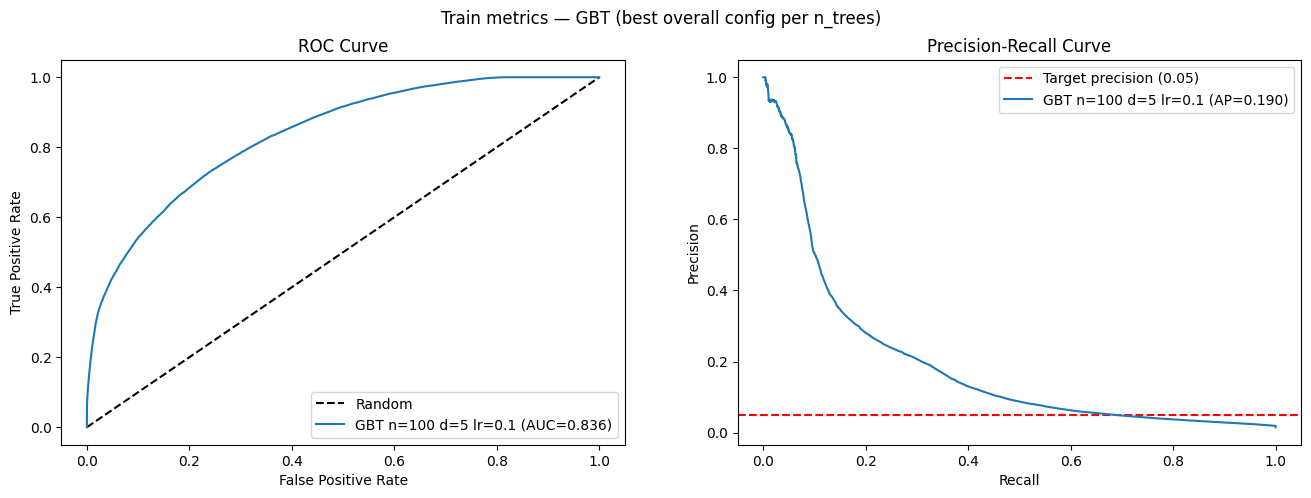

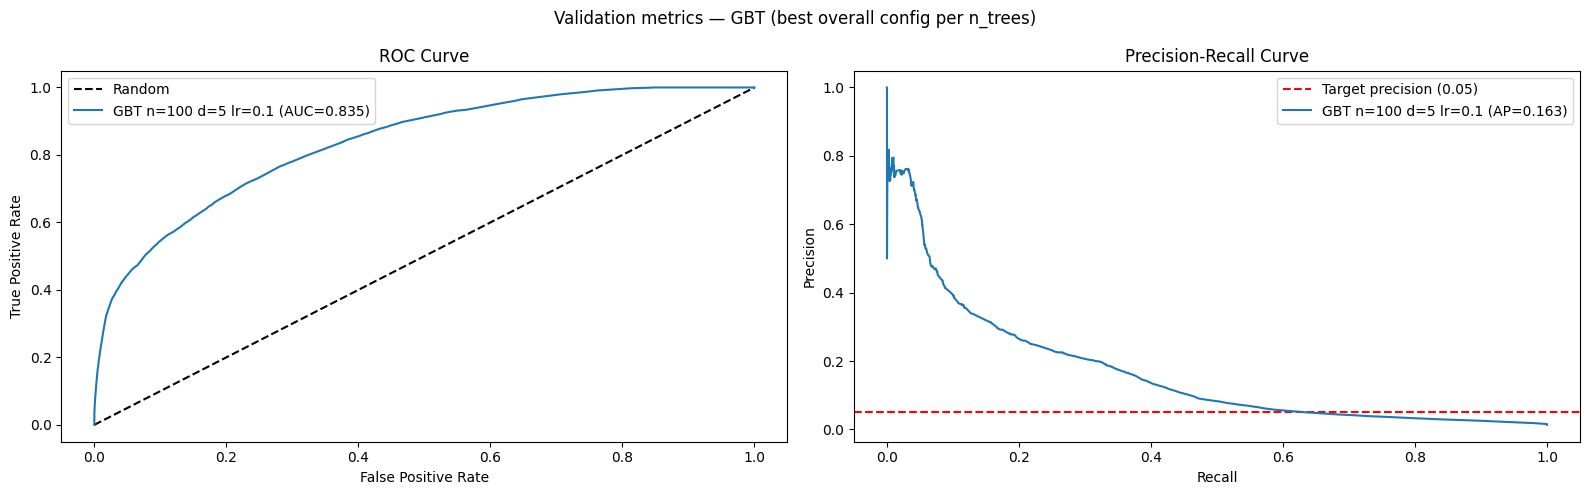

Train logloss: 0.062211
Val   logloss: 0.057363


In [16]:
gbt = GradientBoostingClassifier(
    learning_rate=lr_best, max_depth=max_depth_best, n_estimators=n_estimators_best
)
gbt.fit(X_train, y_train)

train_proba = gbt.predict_proba(X_train)[:, 1]
val_proba   = gbt.predict_proba(X_val)[:, 1]

results.append({
    "train_logloss": log_loss(y_train, train_proba),
    "val_logloss":   log_loss(y_val,   val_proba),
    "train_proba":   train_proba,
    "val_proba":     val_proba,
})

fig_train, ax_train = plt.subplots(1, 2, figsize=(16, 5))
fig_train.suptitle("Train metrics — GBT (best overall config per n_trees)")
fig_val, ax_val = plt.subplots(1, 2, figsize=(16, 5))
fig_val.suptitle("Validation metrics — GBT (best overall config per n_trees)")

label = f"GBT n={n_estimators_best} d={max_depth_best} lr={lr_best}"

plot_metrics(label, y_pred=train_proba, y=y_train,
             figure=(fig_train, ax_train), add_baselines=True)
plot_metrics(label, y_pred=val_proba,   y=y_val,
             figure=(fig_val, ax_val),   add_baselines=True)

plt.tight_layout()
plt.show()

print(f"Train logloss: {results[-1]['train_logloss']:.6f}")
print(f"Val   logloss: {results[-1]['val_logloss']:.6f}")

# Other Models

**CatBoost / XGBoost**
Both could be interesting to check, with CatBoost being particularly relevant due to its native compatibility with categorical features. However, our goal here was to focus on the common process of training and evaluation and compare some representative models — not to go in depth on each potential implementation.

**K-Nearest Neighbours**
Not suitable in this case. KNN computes the distance to all training points at inference time, making it computationally impractical at our dataset size. The cost that other models pay at training time, KNN pays at every single prediction.

**Support Vector Machines**
Two blockers for our use case: SVMs are tremendously slow to fit on large datasets, and they do not naturally output probabilities — which is precisely what we need to adjust our decision threshold on an imbalanced dataset and tune the precision-recall trade-off. Not worth pursuing here. If you want to experiment, remember that feature scaling is essential for SVMs and the regularisation parameter `C` behaves analogously to what we explored in Logistic Regression.

### Comparing our Models

In [17]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)
rf_predictions = rf.predict_proba(X_val)[:, 1]
print("RF trained")

# Gradient Boosting Trees
gbt = GradientBoostingClassifier(
    learning_rate=lr_best, max_depth=max_depth_best, n_estimators=n_estimators_best
)
gbt.fit(X_train, y_train)
gbt_predictions = gbt.predict_proba(X_val)[:, 1]
print("GBT Trained")

# Logistic Regression
lr = make_pipeline(
    StandardScaler(), 
    LogisticRegression(penalty="l2", C=best_ridge["C"], solver="saga"))
lr.fit(X_train, y_train)
lr_predictions = lr.predict_proba(X_val)[:, 1]
print("Logistic Regression trained")

RF trained
GBT Trained
Logistic Regression trained


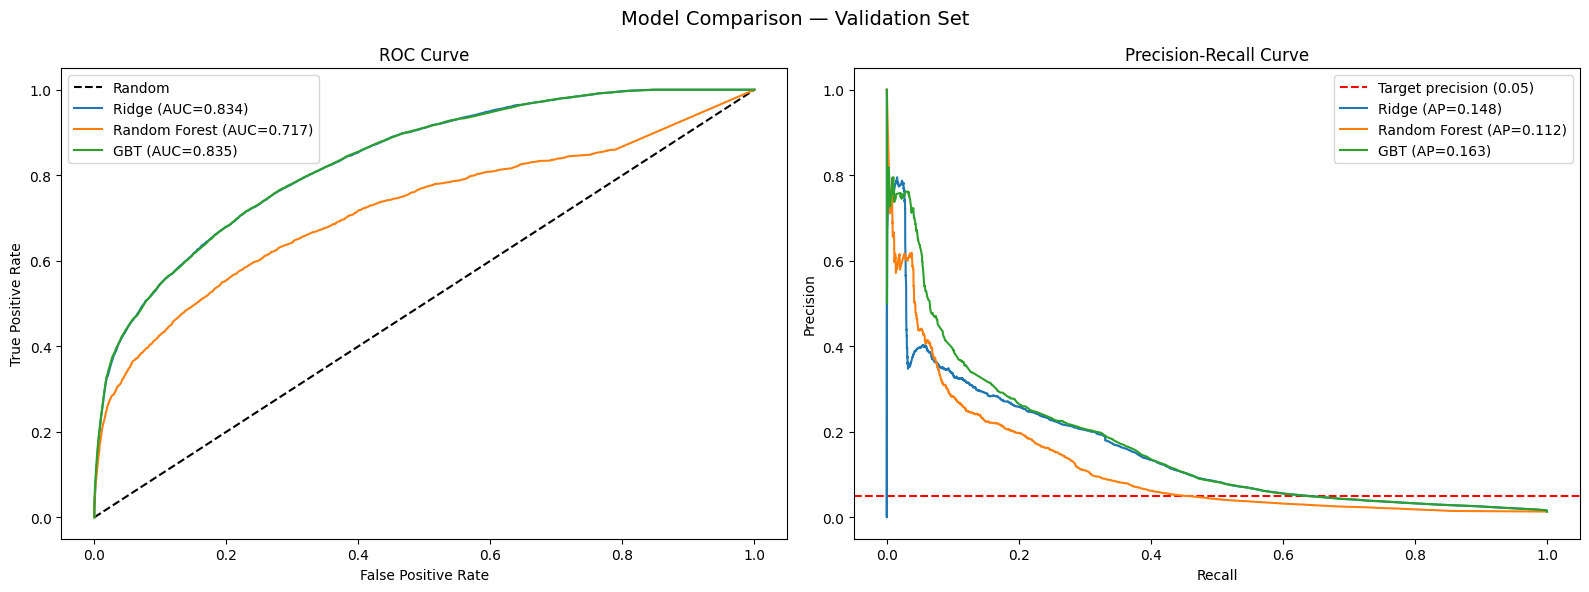

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Model Comparison — Validation Set", fontsize=14)

models = [
    ("Ridge",         lr_predictions),
    ("Random Forest", rf_predictions),
    ("GBT",           gbt_predictions),
]

for i, (model_name, val_proba) in enumerate(models):
    plot_metrics(model_name, y_pred=val_proba, y=y_val,
                 figure=(fig, axes), add_baselines=(i == 0))

plt.tight_layout()
plt.show()

GBT and Ridge outperform Random Forest on both metrics and will be our focus going forward.

### Operating Point Selection

Choosing a threshold is fundamentally a business decision: how costly is missing an interested user 
(low recall) versus sending an unwanted notification (low precision)?

In our case, the PRD tells us that ~5% of push notifications are opened. Treating open rate as a 
proxy for interest, the natural starting point is to target users whose predicted probability exceeds 
this 5% prevalence — any threshold above the baseline positive rate means our model is doing better 
than random targeting.

This is exactly what the red dashed line on the PR curve represents. The question is: at what recall 
can we sustain precision above that line?

# Calibration

In [19]:
lr_prob_true, lr_prob_pred = calibration_curve(y_val, lr_predictions, n_bins=20)
gbt_prob_true, gbt_prob_pred = calibration_curve(y_val, gbt_predictions, n_bins=20)

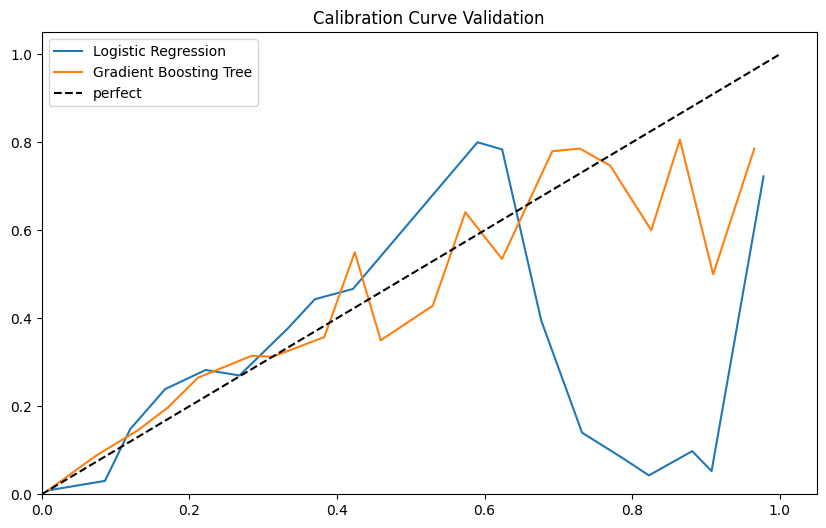

In [20]:
fig, ax = plt.subplots(figsize=(10,6))

ax.plot(lr_prob_pred, lr_prob_true, label="Logistic Regression")
ax.plot(gbt_prob_pred, gbt_prob_true, label="Gradient Boosting Tree")
ax.plot([0, 1], [0, 1], color="k", linestyle="--", label="perfect")
ax.set_ylim(0, 1.05)
ax.set_xlim(0, 1.05)
ax.set_title("Calibration Curve Validation")
ax.legend()

GBT tracks the diagonal more consistently than 
Logistic Regression, which is noticeably noisier. This gives us more confidence that GBT's 
predicted probabilities are meaningful when setting our notification threshold.

In [21]:
calibrated_lr = CalibratedClassifierCV(lr, cv="prefit", method="isotonic")
calibrated_gbt = CalibratedClassifierCV(gbt, cv="prefit", method="isotonic")

In [22]:
calibrated_lr.fit(X_val, y_val)
val_lr_calibrated_pred = calibrated_lr.predict_proba(X_val)[:, 1]
test_lr_calibrated_pred = calibrated_lr.predict_proba(X_test)[:, 1]

calibrated_gbt.fit(X_val, y_val)
val_gbt_calibrated_pred = calibrated_gbt.predict_proba(X_val)[:, 1]
test_gbt_calibrated_pred = calibrated_gbt.predict_proba(X_test)[:, 1]

In [23]:
lr_prob_true_val_calibrated, lr_prob_pred_val_calibrated = calibration_curve(y_val, val_lr_calibrated_pred, n_bins=20)
lr_prob_true_test_calibrated, lr_prob_pred_test_calibrated = calibration_curve(y_test, test_lr_calibrated_pred, n_bins=20)

gbt_prob_true_val_calibrated, gbt_prob_pred_val_calibrated = calibration_curve(y_val, val_gbt_calibrated_pred, n_bins=20)
gbt_prob_true_test_calibrated, gbt_prob_pred_test_calibrated = calibration_curve(y_test, test_gbt_calibrated_pred, n_bins=20)

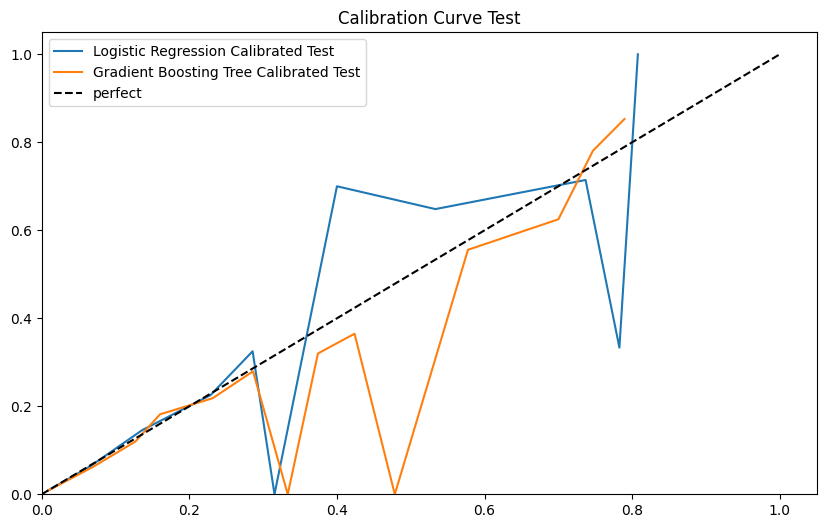

In [24]:
fig, ax = plt.subplots(figsize=(10,6))

ax.plot(lr_prob_pred_test_calibrated, lr_prob_true_test_calibrated, label="Logistic Regression Calibrated Test", color="C0")
ax.plot(gbt_prob_pred_test_calibrated, gbt_prob_true_test_calibrated, label="Gradient Boosting Tree Calibrated Test", color="C1")

ax.plot([0, 1], [0, 1], color="k", linestyle="--", label="perfect")
ax.set_ylim(0, 1.05)
ax.set_xlim(0, 1.05)
ax.set_title("Calibration Curve Test")
ax.legend()

GBT remains better calibrated than Logistic Regression on the test set. Neither model is perfect, 
but both are more reliable than their uncalibrated counterparts for threshold selection.

# Asessing Final Performance

We apply a threshold of 0.05 on the calibrated probabilities — any user with a predicted 
probability above prevalence is considered a notification candidate.

In [ ]:
th = 0.05 # Minimum probability of a user opening the notification (5%)
gbt_test_binary_pred =(test_gbt_calibrated_pred > th).astype(int)
lr_test_binary_pred =(test_lr_calibrated_pred > th).astype(int)

In [27]:
def get_model_binary_metrics(y_true: np.ndarray, y_pred: np.ndarray, name: str = "") -> pd.Series:
    """Compute precision, recall, F1 and positive rate for the positive class."""
    precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred)
    return pd.Series(
        {
            "precision":     precision[1],
            "recall":        recall[1],
            "f1":            f1[1],
            "positive_rate": support[1] / support.sum(),
        },
        name=name,
    )

In [28]:
gbt_test_results = get_model_binary_metrics(y_test, gbt_test_binary_pred, name="gbt")
lr_test_results = get_model_binary_metrics(y_test, lr_test_binary_pred, name="lr")

test_results = pd.concat([gbt_test_results, lr_test_results], axis=1)

In [29]:
test_results

,gbt,lr
precision,0.149628,0.145403
recall,0.373231,0.375295
f1,0.213617,0.209599
positive_rate,0.012874,0.012874


In [ ]:
def get_push_metrics(y_true: np.ndarray, y_score: np.ndarray):
    """Returns precision, recall, PR thresholds, FPR, TPR, ROC thresholds, AUC and AP."""
    precision, recall, pr_thresholds = precision_recall_curve(y_true, y_score)
    fpr, tpr, roc_thresholds        = roc_curve(y_true, y_score)
    auc_score                       = roc_auc_score(y_true, y_score)
    ap                              = average_precision_score(y_true, y_score)
    return precision, recall, pr_thresholds, fpr, tpr, roc_thresholds, auc_score, ap

(
    lr_push_precision, lr_push_recall, lr_push_pr_thresholds,
    lr_push_fpr, lr_push_tpr, lr_push_roc_thresholds,
    lr_push_auc, lr_push_auc_ap,
) = get_push_metrics(y_test, test_lr_calibrated_pred)

(
    gbt_push_precision, gbt_push_recall, gbt_push_pr_thresholds,
    gbt_push_fpr, gbt_push_tpr, gbt_push_roc_thresholds,
    gbt_push_auc, gbt_push_auc_ap,
) = get_push_metrics(y_test, test_gbt_calibrated_pred)

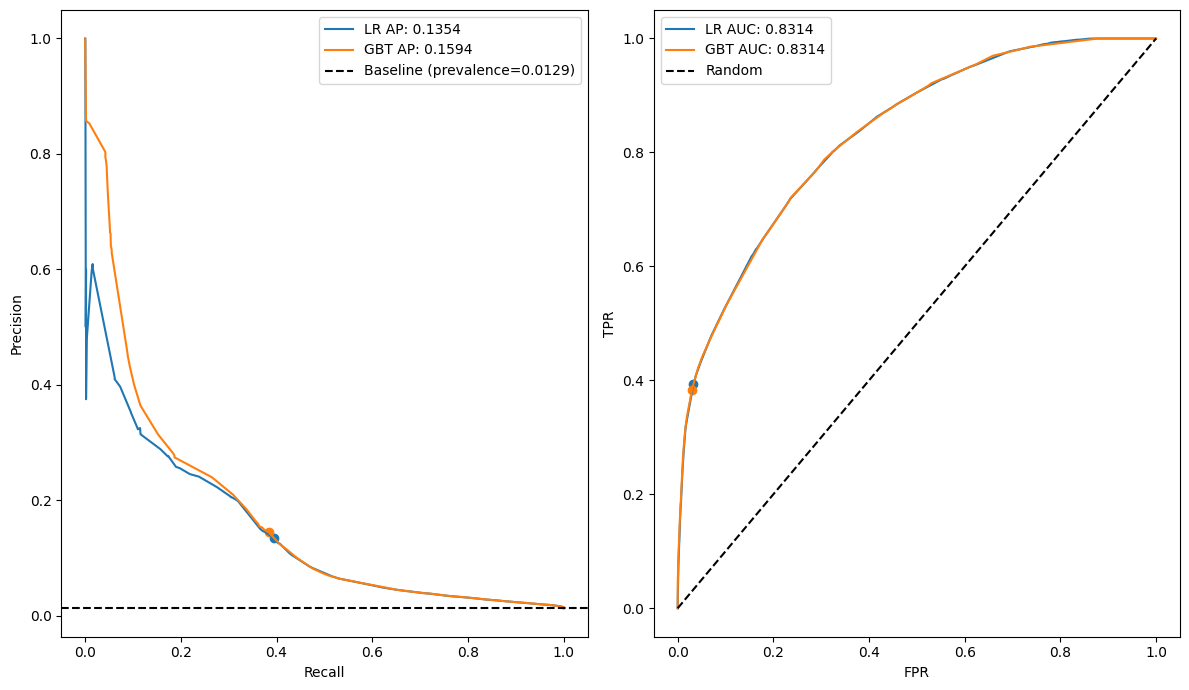

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 7))

prevalence = y_test.mean()

models = [
    ("LR",  lr_push_precision,  lr_push_recall,  lr_push_pr_thresholds,  lr_push_fpr,  lr_push_tpr,  lr_push_roc_thresholds,  lr_push_auc,  lr_push_auc_ap),
    ("GBT", gbt_push_precision, gbt_push_recall, gbt_push_pr_thresholds, gbt_push_fpr, gbt_push_tpr, gbt_push_roc_thresholds, gbt_push_auc, gbt_push_auc_ap),
]

for i, (name, precision, recall, pr_thresholds, fpr, tpr, roc_thresholds, auc, ap) in enumerate(models):
    pr_th  = np.argmin(np.abs(pr_thresholds  - th))
    roc_th = np.argmin(np.abs(roc_thresholds - th))

    axes[0].plot(recall, precision, label=f"{name} AP: {ap:.4f}")
    axes[0].scatter(recall[pr_th], precision[pr_th], color=f"C{i}")

    axes[1].plot(fpr, tpr, label=f"{name} AUC: {auc:.4f}")
    axes[1].scatter(fpr[roc_th], tpr[roc_th], color=f"C{i}")

axes[0].axhline(prevalence, linestyle="--", color="k", label=f"Baseline (prevalence={prevalence:.4f})")
axes[0].set(xlabel="Recall", ylabel="Precision")

axes[1].plot([0, 1], [0, 1], linestyle="--", color="k", label="Random")
axes[1].set(xlabel="FPR", ylabel="TPR")

for ax in axes:
    ax.legend()

plt.tight_layout()
plt.show()

# Checking New Users Only

We split test users into two groups: those seen during training or validation (**old users**) and 
those appearing for the first time (**new users**). This tells us whether the model generalises 
to unseen users — the more realistic production scenario.

In [37]:
train_users    = df_train["user_id"].unique()
val_users      = df_val["user_id"].unique()
test_users     = df_test["user_id"].unique()

train_val_users = np.union1d(train_users, val_users)
new_test_users  = np.setdiff1d(test_users, train_val_users)
old_test_users  = np.intersect1d(test_users, train_val_users)

In [38]:
new_test_users_mask = df_test["user_id"].isin(new_test_users).values
old_test_users_mask = df_test["user_id"].isin(old_test_users).values

In [39]:
gbt_new_users_test_results = get_model_binary_metrics(y_test[new_test_users_mask], gbt_test_binary_pred[new_test_users_mask], name="GBT New Users")
gbt_old_users_test_results = get_model_binary_metrics(y_test[old_test_users_mask], gbt_test_binary_pred[old_test_users_mask], name="GBT Old Users")

lr_new_users_test_results  = get_model_binary_metrics(y_test[new_test_users_mask], lr_test_binary_pred[new_test_users_mask],  name="LR New Users")
lr_old_users_test_results  = get_model_binary_metrics(y_test[old_test_users_mask], lr_test_binary_pred[old_test_users_mask],  name="LR Old Users")

pd.concat([gbt_new_users_test_results, gbt_old_users_test_results, lr_new_users_test_results, lr_old_users_test_results], axis=1).T

,precision,recall,f1,positive_rate
GBT New Users,0.156062,0.303738,0.206186,0.012004
GBT Old Users,0.145447,0.444048,0.219122,0.013901
LR New Users,0.154254,0.306075,0.205128,0.012004
LR Old Users,0.139791,0.445833,0.212845,0.013901


Old users achieve a higher F1 score than new users across both models, driven by significantly 
higher recall — the model leverages prior purchase history more effectively for known users. And for new users the recall works much worse.

### Checking some individual items

Prediction quality likely varies across products — it is worth investigating which ones the model struggles with.

In [42]:
item_popularity = df_test.groupby("variant_id")["outcome"].sum().sort_values(ascending=False)

In [45]:
results_per_item = []

for rank, item in zip([0, 5, 10, 15, 25, 50, 100, 250], item_popularity.index[[0, 5, 10, 15, 25, 50, 100, 250]]):
    item_mask    = df_test["variant_id"] == item
    n_purchases  = y_test[item_mask].sum()

    gbt_item_results = get_model_binary_metrics(y_test[item_mask], gbt_test_binary_pred[item_mask], name=f"GBT popularity_rank={rank}")
    lr_item_results  = get_model_binary_metrics(y_test[item_mask], lr_test_binary_pred[item_mask],  name=f"LR  popularity_rank={rank}")
    
    gbt_item_results["n_purchases"] = n_purchases
    lr_item_results["n_purchases"]  = n_purchases

    results_per_item.extend([gbt_item_results, lr_item_results])

display(pd.concat(results_per_item, axis=1).T)

/home/tomas/.cache/pypoetry/virtualenvs/zrive-ds-kXjcYw89-py3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/tomas/.cache/pypoetry/virtualenvs/zrive-ds-kXjcYw89-py3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/tomas/.cache/pypoetry/virtualenvs/zrive-ds-kXjcYw89-py3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divisi

,precision,recall,f1,positive_rate,n_purchases
GBT popularity_rank=0,0.485549,0.976744,0.648649,0.312727,86.0
LR popularity_rank=0,0.312727,1.000000,0.476454,0.312727,86.0
GBT popularity_rank=5,0.112727,1.000000,0.202614,0.112727,31.0
LR popularity_rank=5,0.112727,1.000000,0.202614,0.112727,31.0
GBT popularity_rank=10,0.072727,1.000000,0.135593,0.072727,20.0
LR popularity_rank=10,0.072727,1.000000,0.135593,0.072727,20.0
GBT popularity_rank=15,0.466667,0.388889,0.424242,0.065455,18.0
LR popularity_rank=15,0.466667,0.388889,0.424242,0.065455,18.0
GBT popularity_rank=25,0.240000,0.375000,0.292683,0.058182,16.0
LR popularity_rank=25,0.240000,0.375000,0.292683,0.058182,16.0


Performance varies significantly across products, and metrics become unreliable for items with very 
few purchases — a natural consequence of splitting an already sparse dataset. Results for low 
purchase count items should not be used to draw conclusions.

# Outcome and Final Insights

- **Gradient Boosting Trees** are the best performing model, though the margin over Logistic 
Regression is narrow — both achieve similar results on reduced features, confirming that the 
feature set is the binding constraint rather than model complexity.
- **Logistic Regression** is a strong and simpler contender, easier to maintain and interpret 
in a production setting. 
- **Regularisation** is important for model stability, particularly for Logistic Regression 
where the optimal C was tuned via TimeSeriesSplit cross-validation.
- **Calibration** is essential for our threshold-based notification strategy — uncalibrated 
probabilities cannot be reliably compared against the 5% prevalence baseline. Calibration must 
always be performed on a held-out set to avoid bias.
- **Class imbalance-robust metrics** (AUC and AP) were used throughout. AP is the more 
informative metric in our setting given the heavy class imbalance.
- **Temporal splitting** was used to reflect the non-stationary nature of the business — 
training on past data and evaluating on future data is the only honest simulation of production.
- **Model performance degrades for new users and low-purchase items** — a known limitation 
that should be monitored closely in deployment.